# Definitions

In [74]:
import os
import numba
os.environ["OMP_NUM_THREADS"] =        "1"
os.environ["OPENBLAS_NUM_THREADS"] =   "1"
os.environ["MKL_NUM_THREADS"] =        "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] =    "1"
os.environ["NUMBA_NUM_THREADS"] =      "1" 
os.environ['NUMBA_THREADING_LAYER'] = 'workqueue'  

import numpy as np
import matplotlib.pyplot as pl 
import corner

from astropy.io import fits
from copy import deepcopy 
from exoiris.tslpf import TSLPF
from exoiris.ldtkld import LDTkLD
from exoiris import ExoIris, TSData
from multiprocessing import Pool 
from numpy import atleast_2d, arctan2, dstack, array, sqrt
from petitRADTRANS import physical_constants as nc  
from petitRADTRANS.radtrans import Radtrans 
from petitRADTRANS.chemistry.pre_calculated_chemistry import PreCalculatedEquilibriumChemistryTable
from petitRADTRANS.physics import temperature_profile_function_guillot_global as get_tprofile
from petitRADTRANS.physics import rebin_spectrum_bin
from pytransit.orbits import as_from_rhop, i_from_ba
from pytransit.param import ParameterSet, UniformPrior as UP, NormalPrior as NP, GParameter

NM_WHITE_MARGINALIZED = 0
NM_GP_FIXED = 1
NM_GP_FREE = 2
NM_WHITE_PROFILED = 3

def custom_transit_model(self, pv, copy=True):
    """Evaluates the transit model for parameter vector pv.

    Parameters
    ----------
    pv : numpy.ndarray
        Array of transit parameters. Each row represents a set of transit parameters for a single transit event.
        The columns of the array should be in the following order:
        - Column 0: stellar density (g/cm^3)
        - Column 1: transit center time (T0)
        - Column 2: orbital period (P)
        - Column 3: impact parameter
        - Column 4: sqrt e cos w
        - Column 5: sqrt e sin w
        - Column 6: planet-to-star radius ratio (Rp/R_star)
    """
    pv = atleast_2d(pv)
    k = self.get_radius_ratios(pv) 
    ldp = self._eval_ldc(pv)
    t0s = pv[:, self._sl_tcs]
    p = pv[:, 1] 
    aor = as_from_rhop(pv[:, 0], p)
    inc = i_from_ba(pv[:, 2], aor)
    ecc = pv[:, 3] ** 2 + pv[:, 4] ** 2
    w = arctan2(pv[:, 4], pv[:, 3])
    epids = self.data.epoch_groups
    fluxes = []
    if isinstance(self.ldmodel, LDTkLD):
        ldp, istar = self.ldmodel(self.tms[0].mu, ldp)
        ldpi = dstack([ldp, istar])
        for i, tm in enumerate(self.tms):
            fluxes.append(tm.evaluate(k[i], ldpi[:, self.ldmodel.wlslices[i], :],
                                        t0s[:, epids[i]], p, aor, inc, ecc, w, copy))
    else:
        for i, tm in enumerate(self.tms):
            fluxes.append(tm.evaluate(k[i], ldp[i], t0s[:, epids[i]], p, aor, inc, ecc, w, copy))

    for i, d in enumerate(self.data):
        if d.offset_group > 0:
            biases = pv[:, self._start_bias + d.offset_group - 1][:, None, None]
            fluxes[i] = biases + (1.0 - biases) * fluxes[i]
    return fluxes 

def _init_parameters_new(self):
    self.ps = ParameterSet([])
    self._init_p_star()
    self._init_p_orbit()
    self._init_p_transit_centers()
    self._init_p_limb_darkening()
    self._init_p_atmosphere()
    self._init_p_noise()
    if self._nm == NM_GP_FREE:
        self._init_p_gp()
    self._init_p_bias()
    self.ps.freeze()

def _init_p_atmosphere(self):
    ps = self.ps
    pp = [GParameter('mp', 'planet_mass', 'M_jup', NP(1.0, 1e-2), (0, np.inf)),
          GParameter('ref_p', 'reference pressure', 'log10 bar', UP(-6, 2), (-np.inf, np.inf)),
          GParameter('cloud_p', 'cloud-top pressure', 'log10 bar', UP(-6, 2), (-np.inf, np.inf)),
          GParameter('tp', 'temperature', 'K', UP(300, 3000), (0, np.inf)),
          GParameter('c2o', 'C/O ratio', '', UP(0.1, 1.6), (0, np.inf)),
          GParameter('pmetal', 'metallicity [M/H]', 'log10 solar', UP(-1, 3), (-np.inf, np.inf))
          ]
    ps.add_global_block('atmosphere', pp)
    self._start_atm = ps.blocks[-1].start
    self._sl_atm = ps.blocks[-1].slice

def get_radius_ratios(self, pv):
    radius_ratios = []
    pv_atm = pv[:, self._sl_atm]  
    transit_depths  = np.array([self.get_ts_model(atm_params) for atm_params in pv_atm])  
    for i, _d in enumerate(self.data):
        transit_depths_rebinned = [rebin_spectrum_bin(self.prt_wl, td_row, self.wavelengths[i], bin_widths=self.bandwidths[i]) for td_row in transit_depths]
        radius_ratios.append(sqrt(array(transit_depths_rebinned)))
    return atleast_2d(radius_ratios)

def init_prt_model(self, prt_atmosphere: Radtrans, prt_chem: PreCalculatedEquilibriumChemistryTable, planet_radius=1.0, star_radius=1.0):
    self.prt_atmosphere = prt_atmosphere
    self.prt_wl = 1e4 * prt_atmosphere.get_wavelengths() # A to micron
    self.prt_pbar = prt_atmosphere.pressures*1e-6 # cgs to bar
    self.prt_chem = prt_chem
    self.planet_radius = planet_radius * nc.r_jup_mean # cm 
    self.star_radius = star_radius * nc.r_sun # cm
    return
    
def get_ts_model(self, atm_params):
    planet_mass = atm_params[0] * nc.m_jup # g
    ref_pressure = 10**atm_params[1] # bar
    cloudtop_pbar = 10**atm_params[2] # bar
    
    # calculate the temperature profile
    ref_gravity = nc.G * planet_mass / self.planet_radius**2
    temperatures = np.full_like(self.prt_pbar, atm_params[3])
    # infrared_mean_opacity = atm_params[3]
    # gamma = atm_params[4]
    # intrinsic_temperature = atm_params[5]
    # equilibrium_temperature = atm_params[6]
    # temperatures = get_tprofile(self.prt_pbar, infrared_mean_opacity=infrared_mean_opacity, gamma=gamma, gravities=ref_gravity, intrinsic_temperature=intrinsic_temperature, equilibrium_temperature=equilibrium_temperature)
    
    # calculate chemical abundances
    co_ratios = np.full_like(self.prt_pbar, atm_params[4])
    metallicities = np.full_like(self.prt_pbar, atm_params[5])
    mass_fractions, mmw, nabla_ad = self.prt_chem.interpolate_mass_fractions(
    co_ratios=co_ratios,
    log10_metallicities=metallicities,
    temperatures=temperatures,
    pressures=self.prt_pbar,
    full=True
    )
    for s in self.prt_atmosphere.line_species:
        if s not in mass_fractions:
            mass_fractions[s] = np.full_like(self.prt_pbar, 1e-6)

    # calculate the transmission spectrum
    _, transit_radii, _ = self.prt_atmosphere.calculate_transit_radii(
    temperatures=temperatures,
    mass_fractions=mass_fractions,
    mean_molar_masses=mmw,
    reference_gravity=ref_gravity,
    planet_radius=self.planet_radius,
    reference_pressure=ref_pressure,
    opaque_cloud_top_pressure=cloudtop_pbar,
    ) 
    transit_depths = (transit_radii/self.star_radius)**2

    return transit_depths
    

def generate_bandwidths(self):
    self.bandwidths = []
    for wl in self.wavelengths: 
        dwl = np.zeros_like(wl)
        dwl[:-1] = np.diff(wl)
        dwl[-1] = dwl[-2] 
        self.bandwidths.append(dwl)
    return self.bandwidths

TSLPF.transit_model = custom_transit_model
TSLPF.init_prt_model = init_prt_model
TSLPF.get_ts_model = get_ts_model
TSLPF._init_parameters = _init_parameters_new
TSLPF._init_p_atmosphere = _init_p_atmosphere
TSLPF.get_radius_ratios = get_radius_ratios
TSLPF.generate_bandwidths = generate_bandwidths


# Initialize pRT

In [75]:
species_names = ['H2O', 'CO-NatAbund', 'CO2', 'CH4']

planet_radius = 1.5 * nc.r_jup_mean # cm
planet_mass = 0.8 * nc.m_jup # g
star_radius = 1.0 * nc.r_sun # cm
reference_pressure = 1e-3 # mbar
reference_gravity = nc.G * planet_mass / planet_radius**2 # cm/s^2

atmosphere = Radtrans(
            pressures = np.logspace(-6, 2, 120),
            line_species = species_names, 
            rayleigh_species = ['H2', 'He'],
            gas_continuum_contributors = ['H2-H2', 'H2-He'],
            wavelength_boundaries = [0.95, 5.1],
            line_opacity_mode = 'c-k', )
wavelengths = 1e4 * atmosphere.get_wavelengths() # from cm to micron


Loading Radtrans opacities...
 Loading line opacities of species 'H2O' from file '/home/ubuntu/petitRADTRANS/input_data/opacities/lines/correlated_k/H2O/1H2-16O/1H2-16O__POKAZATEL.R1000_0.3-50mu.ktable.petitRADTRANS.h5'... Done.
 Loading line opacities of species 'CO-NatAbund' from file '/home/ubuntu/petitRADTRANS/input_data/opacities/lines/correlated_k/CO/C-O-NatAbund/C-O-NatAbund__Chubb.R1000_0.3-50mu.ktable.petitRADTRANS.h5'... Done.
 Loading line opacities of species 'CO2' from file '/home/ubuntu/petitRADTRANS/input_data/opacities/lines/correlated_k/CO2/12C-16O2/12C-16O2__UCL-4000.R1000_0.3-50mu.ktable.petitRADTRANS.h5'... Done.
 Loading line opacities of species 'CH4' from file '/home/ubuntu/petitRADTRANS/input_data/opacities/lines/correlated_k/CH4/12C-1H4/12C-1H4__YT34to10.R1000_0.3-50mu.ktable.petitRADTRANS.h5'... Done.
 Successfully loaded all line opacities
 Loading CIA opacities for H2-H2 from file '/home/ubuntu/petitRADTRANS/input_data/opacities/continuum/collision_induced_a

# Calculate temperature profile

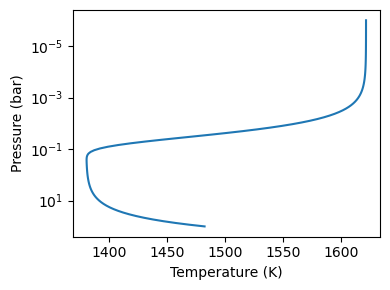

In [76]:
pressures_bar = atmosphere.pressures*1e-6 # cgs to bar
temperatures = get_tprofile(pressures_bar, infrared_mean_opacity=0.01, gamma=2, gravities=1e3, intrinsic_temperature=200, equilibrium_temperature=1500)

fig, ax = pl.subplots(1,1, figsize=(4, 3))
ax.plot(temperatures, pressures_bar) 
ax.set_yscale('log')
ax.invert_yaxis() 
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Pressure (bar)')  
fig.tight_layout()

# Calculate chemical composition

Loading chemical equilibrium chemistry table from file '/home/ubuntu/petitRADTRANS/input_data/pre_calculated_chemistry/equilibrium_chemistry/equilibrium_chemistry.chemtable.petitRADTRANS.h5'... Done.


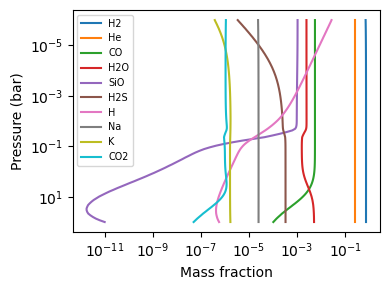

In [77]:
co_ratio = 0.55
metallicity = 0

chem = PreCalculatedEquilibriumChemistryTable()
co_ratios = np.full_like(pressures_bar, co_ratio)
metallicities = np.full_like(pressures_bar, metallicity)

mass_fractions, mmw, nabla_ad = chem.interpolate_mass_fractions(
co_ratios=co_ratios,
log10_metallicities=metallicities,
temperatures=temperatures,
pressures=pressures_bar,
full=True
)
for species in species_names:
    if species not in mass_fractions:
        mass_fractions[species] = np.full_like(pressures_bar, 1e-6)

med_fractions = {s:np.median(v) for s, v in mass_fractions.items()}
top_fractions = dict(sorted(med_fractions.items(), key=lambda kv: kv[1], reverse=True)[:10])

fig, ax = pl.subplots(1,1, figsize=(4, 3))
for species in top_fractions:
    ax.plot(mass_fractions[species], pressures_bar, label=species)
ax.set_yscale('log')
ax.set_xscale('log')
ax.invert_yaxis()
ax.set_xlabel('Mass fraction')
ax.set_ylabel('Pressure (bar)')
ax.legend(fontsize='x-small')
fig.tight_layout()


# Calculate transmission spectrum

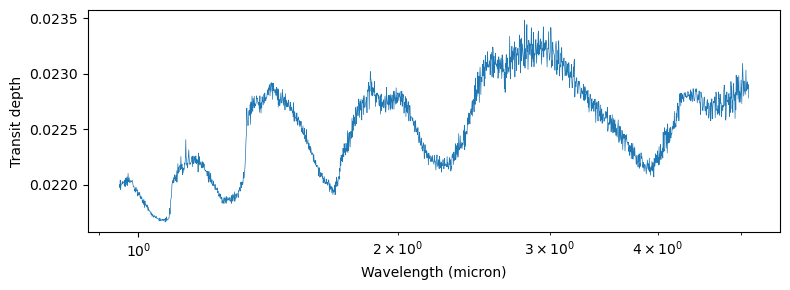

In [78]:
_, transit_radii, _ = atmosphere.calculate_transit_radii(
    temperatures=temperatures,
    mass_fractions=mass_fractions,
    mean_molar_masses=mmw,
    reference_gravity=reference_gravity,
    planet_radius=planet_radius,
    reference_pressure=reference_pressure,
    opaque_cloud_top_pressure=0.1,
)
radius_ratios = transit_radii/star_radius
transit_depths = radius_ratios**2 

fig, ax = pl.subplots(1,1, figsize=(8, 3))
ax.plot(wavelengths, transit_depths, lw=0.5)
ax.set_xscale('log')
ax.set_xlabel('Wavelength (micron)')
ax.set_ylabel('Transit depth')
fig.tight_layout()

# Generate spectroscopic light curves

Try TSLPF with some fake data

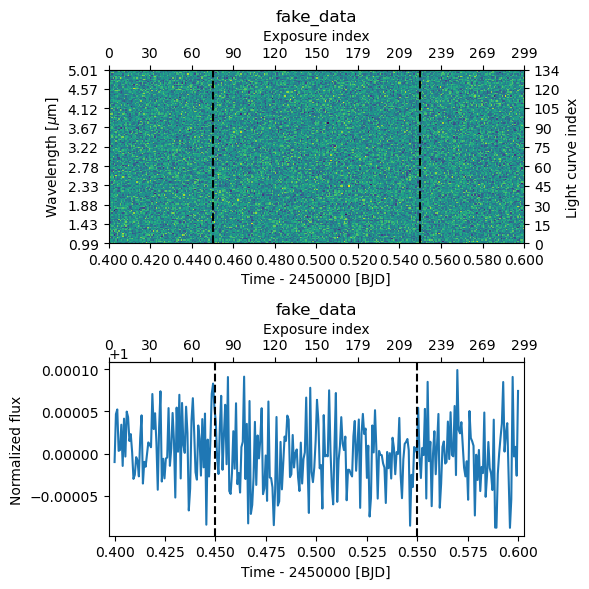

In [79]:
time = np.linspace(-0.1, 0.1, 300) + 2450000.5
fake_wavelengths = np.linspace(1, 5, 135)
fake_fluxes = np.ones([len(fake_wavelengths), len(time)])
fake_errors = 5e-4 * np.ones_like(fake_fluxes)
fake_fluxes += np.random.normal(0, fake_errors, size=fake_fluxes.shape)
fake_data = TSData(time=time, wavelength=fake_wavelengths, fluxes=fake_fluxes, errors=fake_errors, name='fake_data', noise_group=0, n_baseline=1)
fake_data.mask_transit(t0=2450000.5, p=3.0, t14=0.1)

fig, ax = pl.subplots(2, 1, figsize=(6,6))
fake_data.plot(ax=ax[0])
fake_data.plot_white(ax=ax[1])
fig.tight_layout()


# Initialize ExoIris

In [80]:
ldmodel = 'power-2'
print('Initializing LDTk model... It takes several minutes, be patient!')
ldmodel = LDTkLD(data=fake_data, teff=(5500, 100), logg=(4.4, 0.04), metal=(0.0, 0.05), dataset='visir')

print("Initializing ExoIris model...")
exoiris = ExoIris('test', ldmodel=ldmodel, noise_model='white_marginalized', data=fake_data, nk=50, nldc=10, nthreads=1)

exoiris.set_prior('rho', 'NP', 1.4, 0.07)
exoiris.set_prior('p', 'NP', 3.0, 1e-5)
exoiris.set_prior('b', 'UP', 0, 1)
exoiris.set_prior('secw', 'NP', 0, 1e-5)
exoiris.set_prior('sesw', 'NP', 0, 1e-5)
exoiris.set_prior('tc_00', 'NP', 2450000.5, 0.005)
exoiris.set_prior('mp', 'NP', 0.8, 0.01)
exoiris.set_prior('ref_p', 'UP', -6, 2)
exoiris.set_prior('cloud_p', 'UP', -6, 2)
exoiris.set_prior('tp', 'UP', 300, 3000)
exoiris.set_prior('c2o', 'UP', 0.1, 1.6)
exoiris.set_prior('pmetal', 'UP', -1, 3)
exoiris.set_prior('sigma_m_00', 'UP', 0.5, 5)
exoiris.print_parameters()
# exoiris.ps
# exoiris.set_ldtk_prior(teff=(5327, 139), logg=(4.38, 0.05), metal=(-0.01, 0.05), dataset='visir', uncertainty_multiplier=3)

Initializing LDTk model... It takes several minutes, be patient!
Initializing ExoIris model...
  0 |G| rho            N(μ = 1.4, σ = 0.07)                     [    0.00 ..      inf]
  1 |G| p              N(μ = 3.0, σ = 1e-05)                    [    0.00 ..      inf]
  2 |G| b              U(a = 0, b = 1)                          [    0.00 ..      inf]
  3 |G| secw           N(μ = 0.0, σ = 1e-05)                    [   -1.00 ..     1.00]
  4 |G| sesw           N(μ = 0.0, σ = 1e-05)                    [   -1.00 ..     1.00]
  5 |G| tc_00          N(μ = 2450000.5, σ = 0.005)              [    -inf ..      inf]
  6 |G| teff           N(μ = 5500.0, σ = 100.0)                 [    0.00 ..      inf]
  7 |G| logg           N(μ = 4.4, σ = 0.04)                     [    0.00 ..      inf]
  8 |G| metal          N(μ = 0.0, σ = 0.05)                     [    -inf ..      inf]
  9 |G| mp             N(μ = 0.8, σ = 0.01)                     [    0.00 ..      inf]
 10 |G| ref_p          U(a = -6, b 

# Update synthetic fluxes

In [81]:
exoiris._tsa.init_prt_model(atmosphere, chem, planet_radius=1.5, star_radius=1.0)
exoiris._tsa.generate_bandwidths()  
pv_inject = np.array([[1.4, 3.0, 0.1, 0, 0, 2450000.5, 
                     5300.0, 4.4, 0.0,
                     0.8, -3, -1, 1500, 0.55, 0, 
                     2.0]])
fluxes_model = exoiris._tsa.flux_model(pv_inject, include_baseline=False)[0][0]
fluxes_withnoise = fluxes_model + np.random.normal(0, 2*fake_errors)

synthetic_data = TSData(time=time, wavelength=fake_wavelengths, fluxes=fluxes_withnoise, errors=fake_errors, name='synthetic', noise_group=0, n_baseline=1)
synthetic_data.mask_transit(t0=2450000.5, p=3.0, t14=0.1)
exoiris.set_data(synthetic_data)

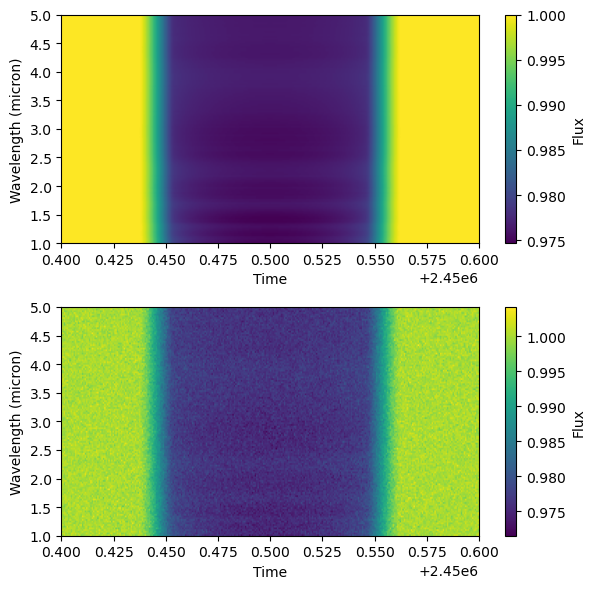

In [82]:
fig, ax = pl.subplots(2,1, figsize=(6,6))
ax[0].imshow(fluxes_model, aspect='auto', origin='lower', extent=[fake_data.time.min(), fake_data.time.max(), fake_data.wavelength.min(), fake_data.wavelength.max()])
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Wavelength (micron)')
fig.colorbar(ax[0].images[0], ax=ax[0], label='Flux')
ax[1].imshow(fluxes_withnoise, aspect='auto', origin='lower', extent=[fake_data.time.min(), fake_data.time.max(), fake_data.wavelength.min(), fake_data.wavelength.max()])
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Wavelength (micron)')
fig.colorbar(ax[1].images[0], ax=ax[1], label='Flux')
fig.tight_layout()

# Run retrievals

Starting with a smoke test

In [ ]:
initial_population = exoiris.ps.sample_from_prior(3)
ll = exoiris._tsa.lnlikelihood(initial_population)
pp = exoiris.lnposterior(initial_population)
print("Evaluating test parameter vectors:")
for val in zip(ll,pp):
    print("ll=%.2f \t\t pp=%.2f" % (val[0], val[1]))

initial_population = exoiris.ps.sample_from_prior(1)
%timeit ll = exoiris._tsa.lnlikelihood(initial_population)

Log-likelihood of the test parameter vectors:
-367092.55
-9019754.81
-406454.59
371 ms ± 1.25 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Global fit using differential evolution

Global optimisation:   0%|          | 0/100 [00:00<?, ?it/s]

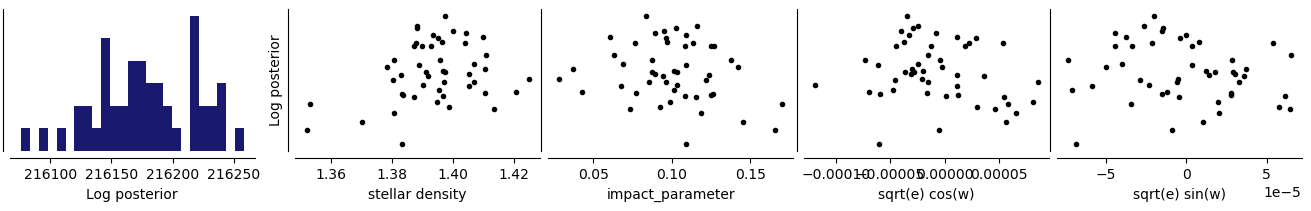

In [84]:
npools = 16
nchains = 3 * npools
niter_de = 100
niter_mcmc = 500

def lnpostf(pv):
    ''' DON'T USE LAMBDA FUNCTION FOR THIS, 
    OTHERWISE IT CAUSES PICKLE ISSUES WITH MULTIPROCESSING '''
    return exoiris.lnposterior(pv) 

init_population = exoiris.ps.sample_from_prior(nchains) 

outputfile = exoiris.name + '.fits'
# if os.path.exists(outputfile):
#     print(f"Output file {outputfile} already exists. Using the calculated DE population.")
#     with fits.open(outputfile) as hdul:
#         de_population = hdul['DE'].data
#     de_population = np.column_stack([de_population[name] for name in de_population.dtype.names])
# else:
with Pool(npools) as pool: 
    exoiris.fit(niter=niter_de, population=init_population, pool=pool, lnpost=lnpostf) 
    de_population = exoiris.de.population
exoiris.save(overwrite=True)
exoiris._tsa._de_population = de_population.copy()

(array([2., 0., 0., 0., 1., 1., 5., 3., 0., 2., 1., 4., 5., 2., 4., 0., 2.,
        2., 2., 4., 0., 3., 1., 2., 2.]),
 array([-0.94300215, -0.84806775, -0.75313335, -0.65819894, -0.56326454,
        -0.46833013, -0.37339573, -0.27846133, -0.18352692, -0.08859252,
         0.00634188,  0.10127629,  0.19621069,  0.2911451 ,  0.3860795 ,
         0.4810139 ,  0.57594831,  0.67088271,  0.76581712,  0.86075152,
         0.95568592,  1.05062033,  1.14555473,  1.24048913,  1.33542354,
         1.43035794]),
 <BarContainer object of 25 artists>)

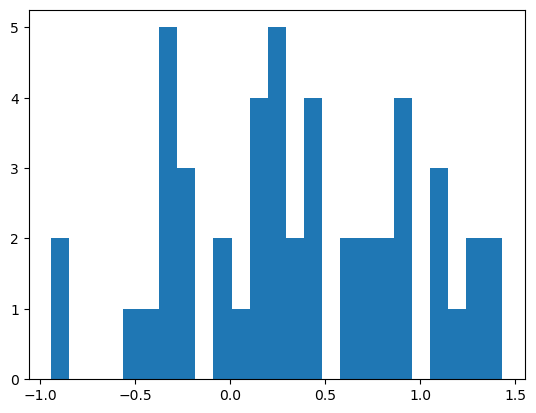

In [85]:
pl.hist(exoiris.de.population[:, -2], bins=25)

In [87]:
exoiris.de.minimum_location

array([ 1.39713413e+00,  2.99996327e+00,  8.32863056e-02, -3.42880468e-05,
       -1.97761186e-05,  2.45000050e+06,  6.17699418e+03,  4.44920923e+00,
        6.37252977e-03,  8.27313124e-01, -3.46255369e+00, -5.44249527e-01,
        1.65422055e+03,  2.48801365e-01, -2.97906841e-01,  1.98492403e+00])

# Run MCMC

In [88]:
with Pool(npools) as pool:
    exoiris.sample(niter=niter_mcmc, thin=1, pool=pool, lnpost=lnpostf)

lnp = exoiris.sampler.get_log_prob()
np.savetxt(exoiris.name + '_lnprob.txt', lnp)

exoiris.save(overwrite=True)

MCMC sampling:   0%|          | 0/1 [00:00<?, ?it/s]

Run 1/1:   0%|          | 0/500 [00:00<?, ?it/s]

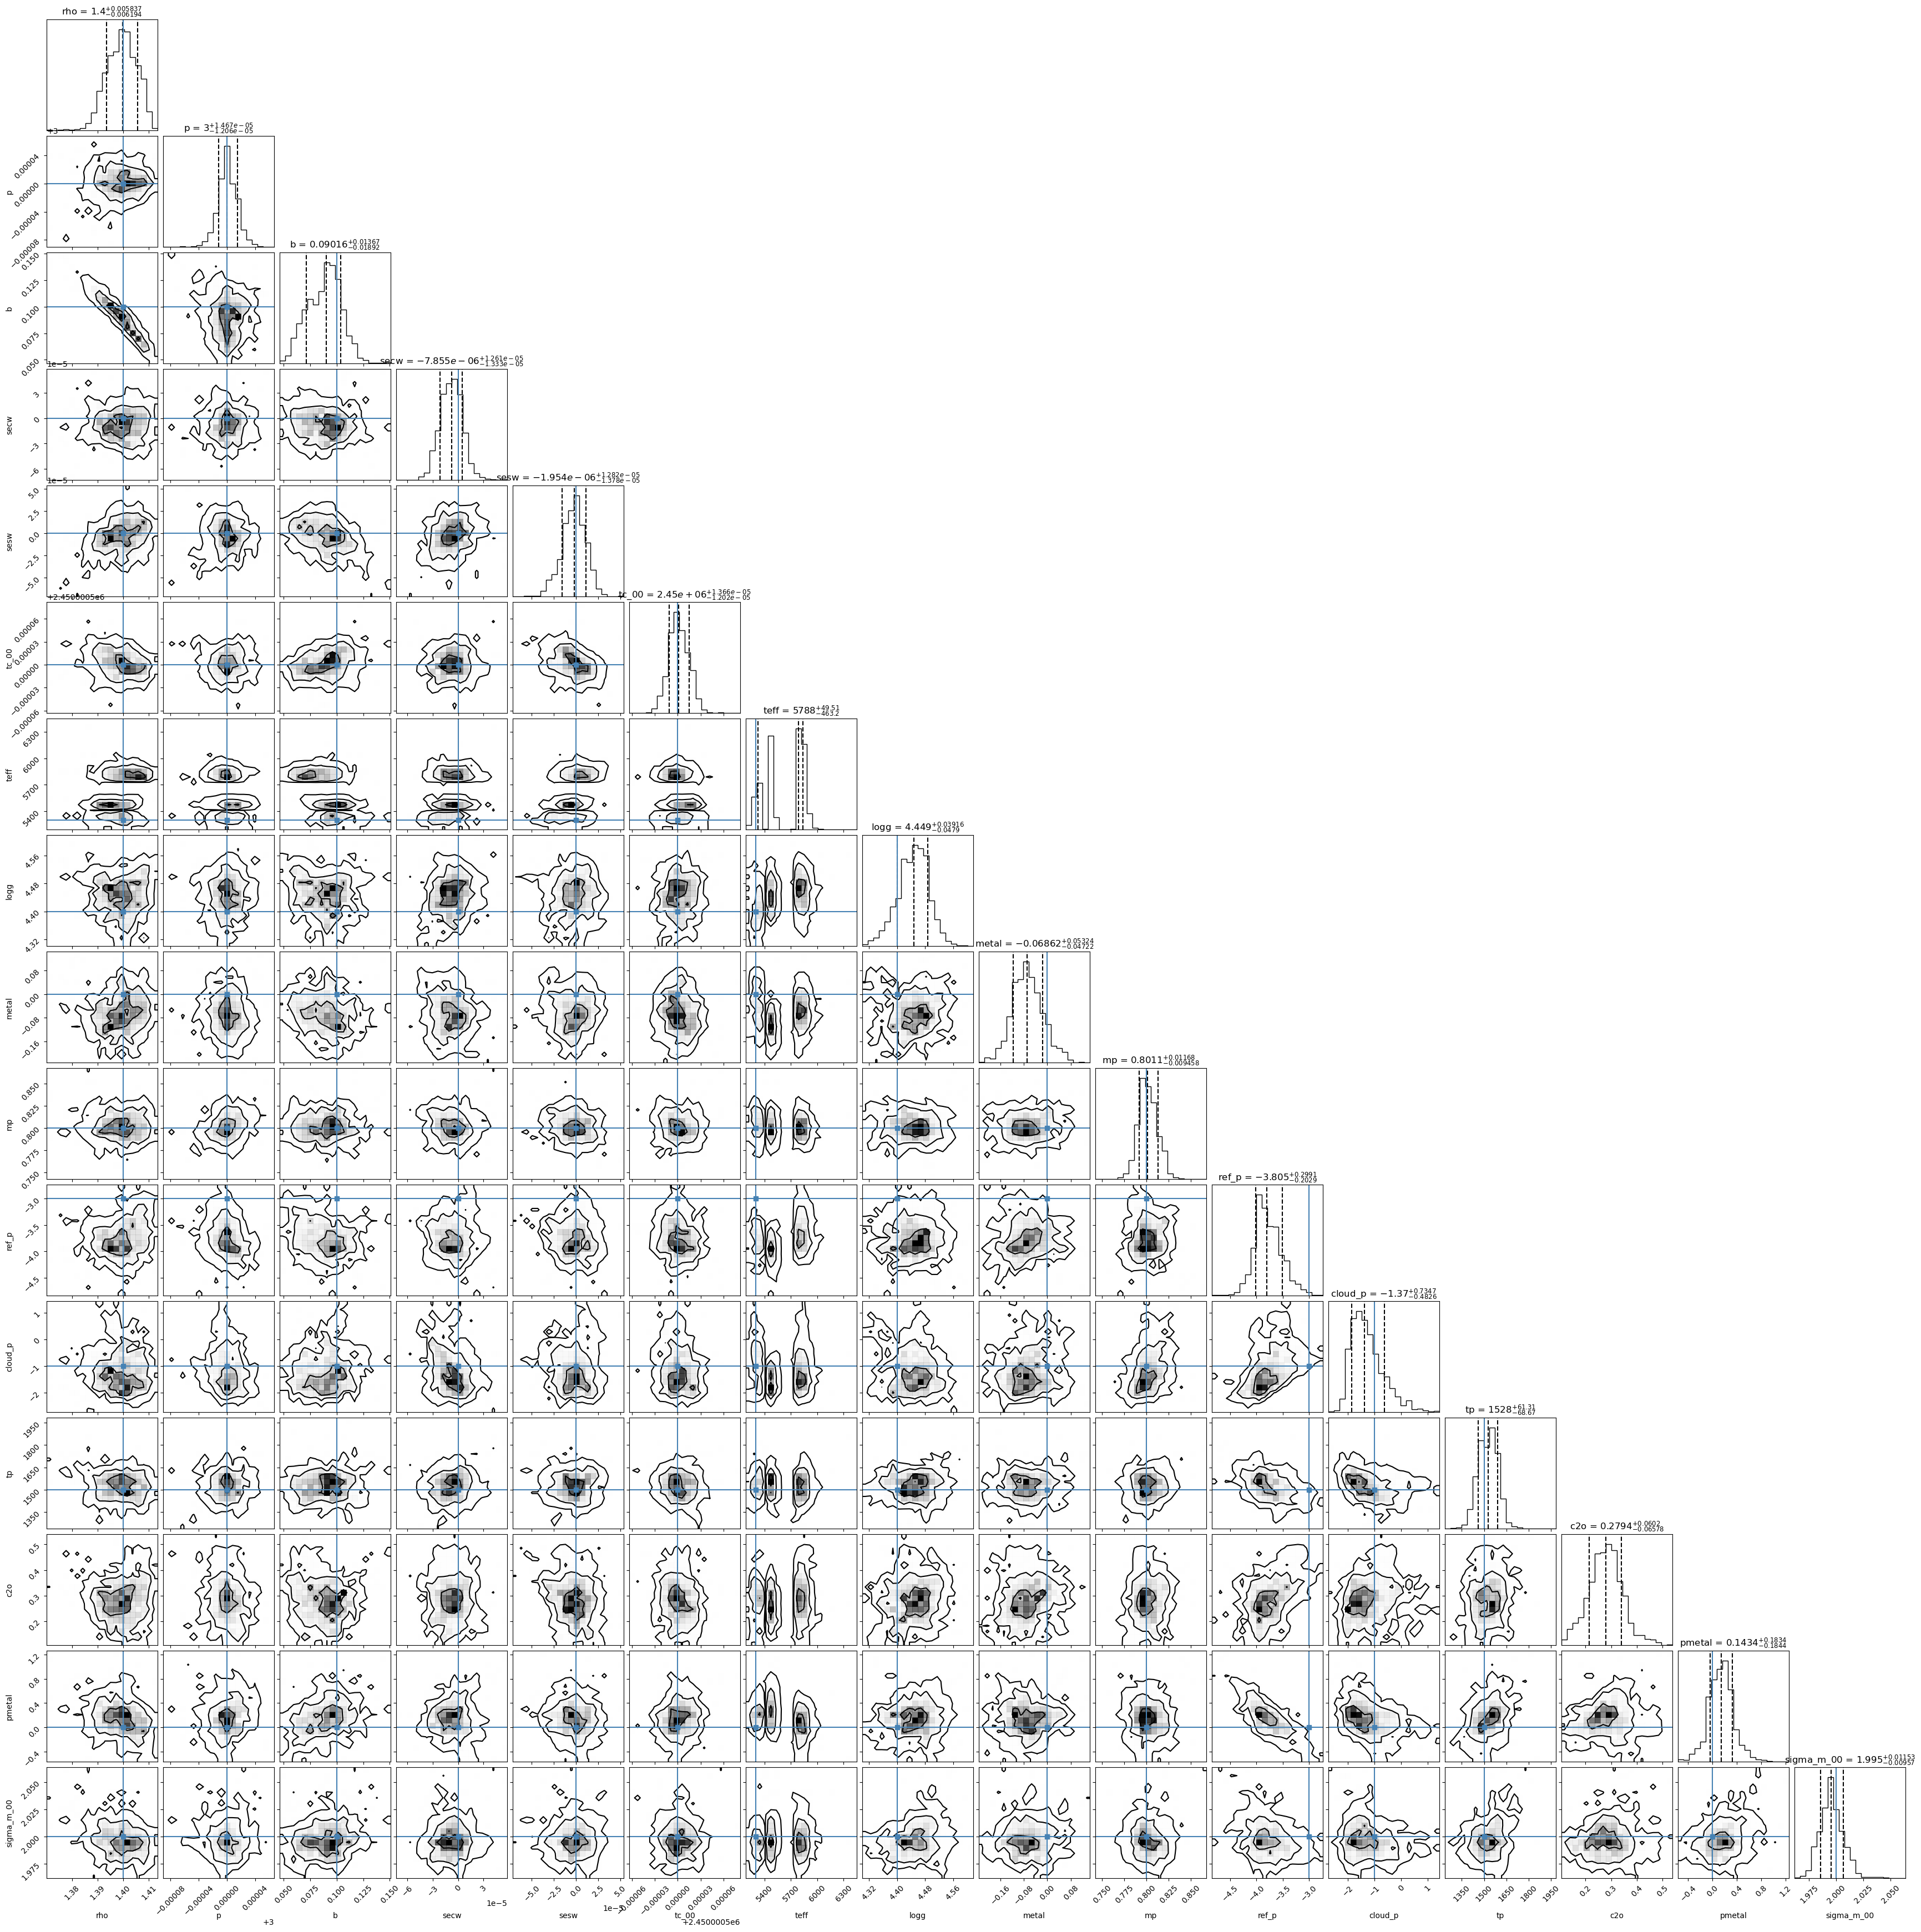

In [90]:
post_samples = exoiris._tsa.sampler.flatchain


labels = [p.name for p in exoiris.ps]
fig = corner.corner(
    post_samples, labels=labels, 
    truths=pv_inject.flatten(),
    show_titles=True, title_fmt='.4g',
    plot_datapoints=False, plot_density=True,
    range=0.999*np.ones(post_samples.shape[1]),
    levels=[0.3935, 0.8647, 0.9889], 
    quantiles=[0.16, 0.5, 0.84],)
# pl.show()
fig.savefig('corner_plot.pdf') 